## Exámen 1 - Práctico
### Objetivo general

La parte practica busca evaluar si el estudiante entiende el flujo completo de modelado visto en clase:

- revision inicial de datos
- analisis exploratorio
- analisis bivariado
- regresion lineal simple
- regresion lineal multiple
- regresion polinomial
- Ridge regression
- StandardScaler
- KNN
- cross validation
- comparacion de modelos usando R2

El objetivo no es solo obtener el mejor R2. El objetivo es que el estudiante explique que hizo, por que lo hizo, que encontro y que significa cada resultado.

## Regla obligatoria para ambos datasets

En cada seccion debe haber una conclusion escrita.

No basta con correr codigo, imprimir tablas o mostrar graficas. Despues de cada analisis o modelo, el estudiante debe explicar con sus palabras:

- que hizo
- que resultado obtuvo
- que significa ese resultado
- si el modelo o variable parece servir
- que decision tomaria con base en el resultado

Si una seccion no tiene interpretacion o conclusion, esta incompleta aunque el codigo funcione.

Dependiendo el que te toque (hitters o boston) 

la idea es que apliques todo lo que vimos en clase, hagas varioa modelos y des conclusiones

 

## 1. Revisión inicial de los datos

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [10]:
df = pd.read_csv('../Data/Hitters_examen.csv')

In [11]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [12]:
df.shape

(322, 20)

In [13]:
df.dtypes

AtBat          int64
Hits           int64
HmRun          int64
Runs           int64
RBI            int64
Walks          int64
Years          int64
CAtBat         int64
CHits          int64
CHmRun         int64
CRuns          int64
CRBI           int64
CWalks         int64
League        object
Division      object
PutOuts        int64
Assists        int64
Errors         int64
Salary       float64
NewLeague     object
dtype: object

In [14]:
df.isna().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [15]:
df = df.dropna()

In [16]:
df.isna().sum()

AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

### Conclusión de la revisión inicial



Primero revise el dataset y tenia 322 observaciones con 20 variables
vi que Salary tenia 59 valores faltantes y como es la variable que quiero predecir elimine esas filas
despues de eso quedaron 263 observaciones
tambien hay variables numericas y 3 categoricas que son League Division y NewLeague entonces mas adelante tengo que tomarlas en cuenta dependiendo del modelo

## 2. Análisis exploratorio

### Conclusión del análisis exploratorio

En el analisis exploratorio revise las estadisticas de Salary. El salario promedio es de 535.93 y la mediana es de 425 entonces hay algunos salarios altos que hacen que aumente el promedio

El 75% de los jugadores tiene un salario de 750 o menos mientras que el maximo llega hasta 2460  esto muestra que hay algunos jugadores con salarios bastante mas altos que el resto

No voy a eliminar estos valores porque pueden ser datos reales y pueden aportar informacion al modelo.

## 3. Análisis bivariado

In [19]:
df_corr = df.copy()

del df_corr['League']
del df_corr['Division']
del df_corr['NewLeague']

df_corr.corr()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
AtBat,1.000000,0.963969,0.555102,0.899829,0.796015,0.624448,0.012725,0.207166,0.225341,0.212422,0.237278,0.221393,0.132926,0.309607,0.342117,0.325577,0.394771
Hits,0.963969,1.000000,0.530627,0.910630,0.788478,0.587311,0.018598,0.206678,0.235606,0.189364,0.238896,0.219384,0.122971,0.299688,0.303975,0.279876,0.438675
HmRun,0.555102,0.530627,1.000000,0.631076,0.849107,0.440454,0.113488,0.217464,0.217496,0.492526,0.258347,0.349858,0.227183,0.250931,-0.161602,-0.009743,0.343028
Runs,0.899829,0.910630,0.631076,1.000000,0.778692,0.697015,-0.011975,0.171811,0.191327,0.229701,0.237831,0.202335,0.163700,0.271160,0.179258,0.192609,0.419859
RBI,0.796015,0.788478,0.849107,0.778692,1.000000,0.569505,0.129668,0.278126,0.292137,0.442190,0.307226,0.387777,0.233619,0.312065,0.062902,0.150155,0.449457
Walks,0.624448,0.587311,0.440454,0.697015,0.569505,1.000000,0.134793,0.269450,0.270795,0.349582,0.332977,0.312697,0.429140,0.280855,0.102523,0.081937,0.443867
Years,0.012725,0.018598,0.113488,-0.011975,0.129668,0.134793,1.000000,0.915681,0.897844,0.722371,0.876649,0.863809,0.837524,-0.020019,-0.085118,-0.156512,0.400657
CAtBat,0.207166,0.206678,0.217464,0.171811,0.278126,0.269450,0.915681,1.000000,0.995057,0.801676,0.982747,0.950730,0.906712,0.053393,-0.007897,-0.070478,0.526135
CHits,0.225341,0.235606,0.217496,0.191327,0.292137,0.270795,0.897844,0.995057,1.000000,0.786652,0.984542,0.946797,0.890718,0.067348,-0.013144,-0.068036,0.548910
CHmRun,0.212422,0.189364,0.492526,0.229701,0.442190,0.349582,0.722371,0.801676,0.786652,1.000000,0.825625,0.927903,0.810878,0.093822,-0.188886,-0.165369,0.524931


La variable con mayor correlacion con Salary es CRBI con 0.566966, despues esta CRuns con 0.562678 y CHits con 0.548910
Asi que voy a utilizar CRBI 

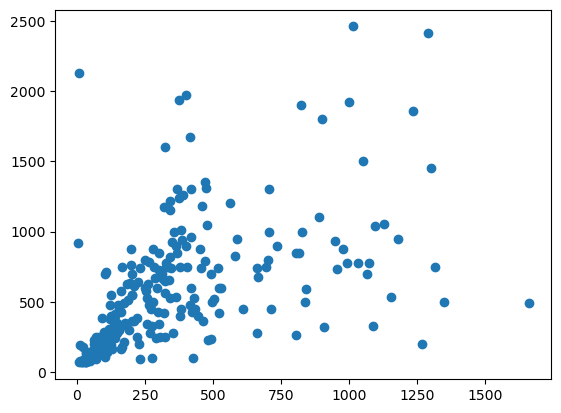

In [20]:
# Grafica CRBI vs Salary
plt.scatter(df.CRBI, df.Salary)
plt.show()

### Conclusión del análisis bivariado



En el analisis bivariado revise la relacion de las variables numericas con Salary usando la matriz de correlacion.  
La variable con mayor relacion fue CRBI con una correlacion de 0.566966, despues CRuns con 0.562678 y CHits con 0.548910

Tambien grafique CRBI contra Salary y se observa una relacion positiva, conforme aumenta CRBI tambien tiende a aumentar el salario aunque existe bastante dispersion entre los datos

Por esto CRBI parece ser una buena variable para comenzar el modelado pero por si sola no explica completamente Salary. La voy a utilizar primero en una regresion lineal simple y despues comparar con modelos que incluyan mas variables

## 4. Regresión lineal simple

In [21]:
X = df[['CRBI']]
y = df['Salary']

model = LinearRegression().fit(X,y)
predicciones = model.predict(X)
from sklearn.metrics import r2_score

r2_simple = r2_score(y_pred=predicciones, y_true=y)
r2_simple


0.3214500886678947

In [22]:
model.intercept_

np.float64(274.58038640752204)

In [23]:
model.coef_

array([0.79095357])

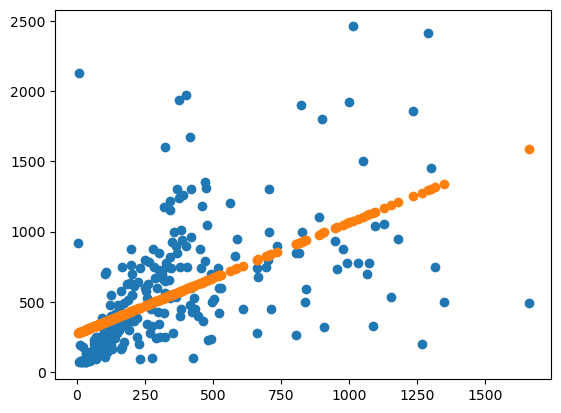

In [24]:
 # Visualiza las predicciones del modelo 
plt.scatter(df.CRBI, df.Salary)
plt.scatter(df.CRBI, predicciones)

### Conclusión de regresión lineal simple



Use CRBI para hacer la regresion lineal simple porque fue la variable que tuvo mayor correlacion con Salary

El modelo dio un R2 de 0.3215 entonces explica aproximadamente el 32.15% de la variacion de Salary. Si aporta informacion pero todavia queda una parte bastante grande que el modelo no explica

La ecuacion fue:

$$Salary = 274.58 + 0.79095(CRBI)$$

Esto quiere decir que por cada unidad que aumenta CRBI el Salary que predice el modelo aumenta aproximadamente 0.79

En la grafica se ve que el modelo sigue una tendencia positiva pero muchos puntos reales quedan lejos de las predicciones  entonces CRBI si ayuda pero usar solo esta variable no es suficiente

Por eso ahora voy a probar una regresion lineal multiple para ver si usando mas variables mejora el R2

## 5. Regresión lineal múltiple

In [25]:
X = df_corr.copy()
del X['Salary']

y = df_corr['Salary']

model = linear_model.LinearRegression().fit(X,y)

In [26]:
predicciones_todo = model.predict(X)

In [27]:
r2_multiple = r2_score(y_pred=predicciones_todo, y_true=y)
r2_multiple

0.5279308277431296

In [28]:
model.intercept_

np.float64(126.10552646450839)

In [29]:
betas = pd.DataFrame({
    'variables': X.keys(),
    'betas': model.coef_.ravel()
})
betas

,variables,betas
0,AtBat,-2.203022
1,Hits,7.827762
2,HmRun,2.163546
3,Runs,-2.099567
4,RBI,-0.022916
5,Walks,6.151061
6,Years,-2.592368
7,CAtBat,-0.176276
8,CHits,0.069762
9,CHmRun,-0.233088


### Conclusión de regresión lineal múltiple



En la regresion lineal multiple use todas las variables numericas para predecir Salary

El modelo dio un R2 de 0.5279 entonces explica aproximadamente el 52.79% de la variacion de Salary. Este resultado fue mejor que el modelo simple que tenia un R2 de 0.3215

Entonces agregar mas variables si ayudo bastante al modelo porque ahora puede explicar una mayor parte de Salary aunque todavia queda casi la mitad de la variacion sin explicar

Por eso ahora conviene probar modelos mas flexibles para ver si se puede mejorar el resultado

## 6. Regresión polinomial

In [30]:
X = df[['CRBI']]
y = df['Salary']

In [31]:
# Regresion polinomial grado 2
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = linear_model.LinearRegression()
model.fit(X_poly, y)

df['predicciones_polinimio2'] = model.predict(X_poly)
r2_poly =r2_score(y_pred=df.predicciones_polinimio2, y_true=y)
r2_poly

0.40109210377921634

In [32]:
model = Pipeline([
    ('poly', PolynomialFeatures()),
    ('regression', linear_model.LinearRegression())
])

# Grados a probar
param_grid = {
    'poly__degree': range(1, 5)
}

# Cross-validation
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='r2'
)
grid.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('regression', LinearRegression())]),
             param_grid={'poly__degree': range(1, 5)}, scoring='r2')

In [33]:
grid.best_params_

{'poly__degree': 2}

### Conclusión de regresión polinomial



Primero probe una regresion polinomial de grado 2 usando CRBI para predecir Salary y obtuvo un R2 de 0.4011. Este resultado fue mejor que la regresion lineal simple que habia dado 0.3215 entonces permitir una relacion curva si ayudo al modelo

Despues use GridSearchCV para comparar los grados 1 al 4 usando cross validation y el mejor grado fue 2

Entonces para esta variable el grado 2 funciona mejor que usar solamente una linea recta pero aun asi explica aproximadamente el 40.11% de la variacion de Salary. El modelo multiple sigue teniendo un R2 mayor con 0.5279

## 7. Ridge Regression

In [34]:
X = df_corr.copy()
del X['Salary']

y = df_corr['Salary']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [36]:
modelo_lineal = make_pipeline(StandardScaler(), LinearRegression())
modelo_ridge = make_pipeline(StandardScaler(), Ridge(alpha=30))

modelo_lineal.fit(X_train, y_train)
modelo_ridge.fit(X_train, y_train)

pred_lineal = modelo_lineal.predict(X_test)
pred_ridge = modelo_ridge.predict(X_test)

In [37]:
r2_score(y_pred=pred_lineal, y_true=y_test)

0.381990722043813

In [38]:
r2_ridge=r2_score(y_pred=pred_ridge, y_true=y_test)
r2_ridge

0.3375678329455556

### Conclusión de Ridge



Para Ridge dividi los datos en train y test y compare el modelo lineal contra Ridge usando las mismas variables

La regresion lineal obtuvo un R2 de 0.3820 en test mientras que Ridge obtuvo 0.3376 entonces en este caso Ridge con alpha=30 no mejoro el modelo

Ridge reduce el peso de los coeficientes para evitar que el modelo se ajuste demasiado pero eso no significa que siempre vaya a aumentar el R2. En este caso la penalizacion hizo que el resultado fuera un poco peor

Despues voy a probar otras formas de validar los modelos para no quedarme solamente con esto.

## 8. StandardScaler

In [39]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [40]:
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors
0,-0.602900,-0.595675,-0.528551,-1.206112,-0.522063,-0.097527,1.397893,0.346791,0.174373,-0.002920,-0.121671,0.258966,0.435334,1.221499,-0.523191,0.213352
1,0.512542,0.492260,0.729966,0.441515,0.794060,1.609373,-0.901200,-0.452865,-0.409892,-0.076054,-0.415105,-0.199590,0.010373,2.109109,-0.253863,0.819964
2,0.628167,0.736490,0.958788,0.402286,1.026317,-0.189792,0.770868,1.301558,1.318174,1.898565,1.412051,1.572666,0.355654,-0.324661,-0.744179,-0.848219
3,-0.562092,-0.462459,-0.185319,-0.617673,-0.367225,-0.512719,-1.110209,-0.990935,-0.960153,-0.697693,-0.947521,-0.881228,-0.862315,1.840678,-0.543909,-0.696566
4,1.294712,1.358167,-0.871783,0.755349,-0.018840,-0.282057,0.770868,0.766993,0.634985,-0.612370,0.422846,0.017294,-0.251434,-0.031177,2.087225,2.488147


In [41]:
resumen = pd.DataFrame({
    'promedio antes': X.mean(),
    'desv_est antes': X.std(),
    'promedio después': df_scaled.mean().values,
    'desv_est después': df_scaled.std().values,
})

resumen.round(3)

,promedio antes,desv_est antes,promedio después,desv_est después
AtBat,403.643,147.307,0.0,1.002
Hits,107.829,45.125,0.0,1.002
HmRun,11.620,8.757,0.0,1.002
Runs,54.745,25.540,-0.0,1.002
RBI,51.487,25.883,0.0,1.002
Walks,41.114,21.718,0.0,1.002
Years,7.312,4.794,-0.0,1.002
CAtBat,2657.544,2286.583,0.0,1.002
CHits,722.186,648.200,0.0,1.002
CHmRun,69.240,82.198,0.0,1.002


### Conclusión de StandardScaler



Use StandardScaler para poner todas las variables en una escala parecida

Antes de escalar se ve que algunas variables tenian promedios y desviaciones mucho mas grandes que otras  despues del escalamiento todas quedaron con promedio cercano a 0 y desviacion cercana a 1

Esto sirve para que una variable no tenga mas peso solo porque sus valores son mas grandes

Ya lo use en Ridge y tambien lo voy a usar en KNN porque KNN calcula distancias y ahi la escala de las variables si afecta bastante

## 9. KNN

In [42]:
X = df_corr.drop('Salary', axis=1)
y = df_corr['Salary']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [44]:
valores_k = np.arange(1, 51)
r2_results = []
rmse_results = []

for k in valores_k:
    modelo = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors=k))
    ])
    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)

    r2_results.append(r2_score(y_test, predicciones))
    rmse_results.append(np.sqrt(mean_squared_error(y_test, predicciones)))

In [45]:
resultados_k = pd.DataFrame({
    'k': valores_k,
    'R2 prueba': r2_results,
    'RMSE prueba': rmse_results,
})

resultados_k.sort_values('R2 prueba', ascending=False).head(10).round(3)

,k,R2 prueba,RMSE prueba
3,4,0.464,360.863
2,3,0.454,364.239
4,5,0.450,365.386
5,6,0.436,370.010
8,9,0.403,380.793
6,7,0.400,381.661
7,8,0.400,381.682
10,11,0.393,383.943
9,10,0.392,384.331
12,13,0.390,384.756


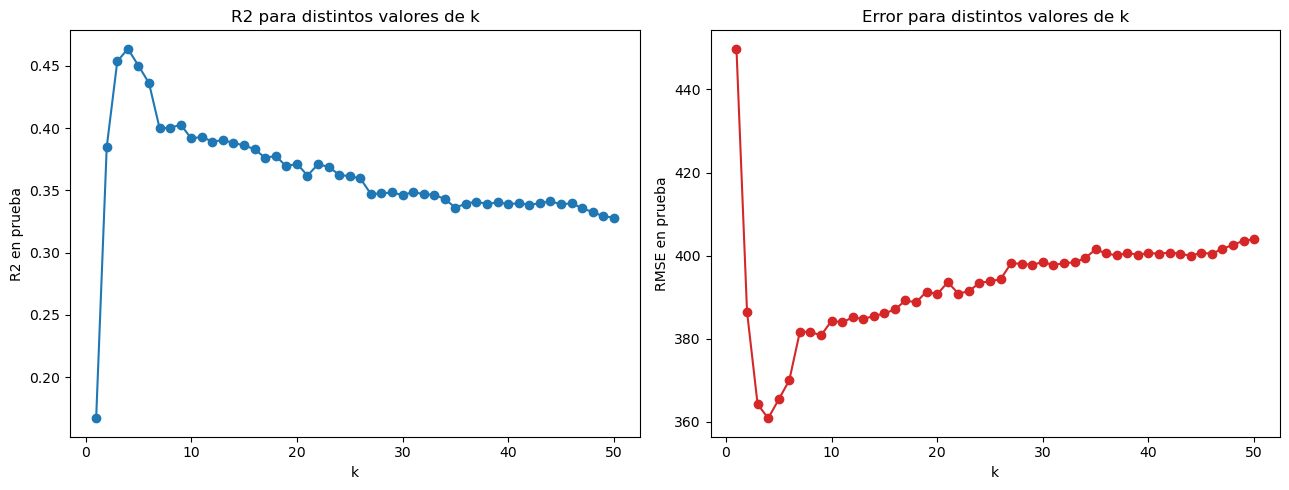

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(resultados_k['k'], resultados_k['R2 prueba'], marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('R2 en prueba')
axes[0].set_title('R2 para distintos valores de k')

axes[1].plot(resultados_k['k'], resultados_k['RMSE prueba'], marker='o', color='tab:red')
axes[1].set_xlabel('k')
axes[1].set_ylabel('RMSE en prueba')
axes[1].set_title('Error para distintos valores de k')

plt.tight_layout()
plt.show()


### Conclusión de KNN

Para KNN use todas las variables numericas y las escale con StandardScaler porque este modelo calcula distancias y la escala de las variables puede afectar el resultado

Probe valores de k del 1 al 50 y compare cada uno usando R2 y RMSE. El mejor resultado fue con k=4 con un R2 de 0.464 y un RMSE de 360.863

Esto significa que usando los 4 vecinos mas cercanos el modelo explica aproximadamente el 46.4% de la variacion de Salary. Tambien se puede ver en las graficas que despues de k=4 el R2 empieza a bajar y el error empieza a aumentar

Entonces para esta division de train y test k=4 fue el valor que mejor funciono


## 10. Cross validation

In [47]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

In [48]:
param_grid = {
    'knn__n_neighbors': range(1, 51)
}

In [49]:
grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsRegressor())]),
             param_grid={'knn__n_neighbors': range(1, 51)}, scoring='r2')

In [50]:
grid.best_params_

{'knn__n_neighbors': 6}

In [51]:
grid.best_score_

np.float64(0.470019149562802)

In [52]:
modelo_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=6))
])

modelo_knn.fit(X_train, y_train)

pred_knn = modelo_knn.predict(X_test)

r2_knn = r2_score(y_test, pred_knn)
r2_knn

0.4362128085552124

### Conclusión de Cross Validation

Use cross validation con 5 divisiones para elegir mejor el valor de k y no quedarme solamente con una division de train y test

Primero me habia salido k=4 pero usando GridSearchCV el mejor valor fue k=6 con un R2 promedio de 0.4700

Entonces el mejor k puede cambiar dependiendo de como se dividen los datos y por eso cross validation ayuda a escogerlo mejor porque prueba varias veces el modelo

Por eso para KNN me quedaria con k=6 porque fue el que mejor resultado tuvo en cross validation

## 11. Comparación de modelos usando R2

In [53]:
# Variable para regresion simple y polinomial
X_simple = df[['CRBI']]

# Variables para multiple, Ridge y KNN
X_todo = df_corr.copy()
del X_todo['Salary']

y = df['Salary']

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y, test_size=0.3, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_todo, y, test_size=0.3, random_state=42
)

In [54]:
modelo_simple = LinearRegression().fit(X_train_simple, y_train_simple)

pred_simple_test = modelo_simple.predict(X_test_simple)

r2_simple_test = r2_score(
    y_pred=pred_simple_test,
    y_true=y_test_simple
)

r2_simple_test

0.3014922232641635

In [55]:
modelo_multiple = linear_model.LinearRegression().fit(X_train, y_train)

pred_multiple_test = modelo_multiple.predict(X_test)

r2_multiple_test = r2_score(
    y_pred=pred_multiple_test,
    y_true=y_test
)

r2_multiple_test

0.3819907220438121

In [56]:
modelo_poly_test = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('regression', linear_model.LinearRegression())
])

modelo_poly_test.fit(X_train_simple, y_train_simple)

pred_poly_test = modelo_poly_test.predict(X_test_simple)

r2_poly_test = r2_score(
    y_pred=pred_poly_test,
    y_true=y_test_simple
)

r2_poly_test

0.17143714123809262

In [57]:
modelo_ridge_test = make_pipeline(
    StandardScaler(),
    Ridge(alpha=30)
)

modelo_ridge_test.fit(X_train, y_train)

pred_ridge_test = modelo_ridge_test.predict(X_test)

r2_ridge_test = r2_score(
    y_pred=pred_ridge_test,
    y_true=y_test
)

r2_ridge_test

0.3375678329455556

In [58]:
modelo_knn_test = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=6))
])

modelo_knn_test.fit(X_train, y_train)

pred_knn_test = modelo_knn_test.predict(X_test)

r2_knn_test = r2_score(
    y_pred=pred_knn_test,
    y_true=y_test
)

r2_knn_test

0.4362128085552124

In [59]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Regresion lineal simple',
        'Regresion lineal multiple',
        'Regresion polinomial grado 2',
        'Ridge',
        'KNN'
    ],
    'R2 prueba': [
        r2_simple_test,
        r2_multiple_test,
        r2_poly_test,
        r2_ridge_test,
        r2_knn_test
    ]
})

comparacion.sort_values('R2 prueba', ascending=False).round(3)

,Modelo,R2 prueba
4,KNN,0.436
1,Regresion lineal multiple,0.382
3,Ridge,0.338
0,Regresion lineal simple,0.301
2,Regresion polinomial grado 2,0.171


In [60]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Regresion lineal simple',
        'Regresion lineal multiple',
        'Regresion polinomial grado 2',
        'Ridge',
        'KNN'
    ],
    'R2 prueba': [
        r2_simple,
        r2_multiple,
        r2_poly,
        r2_ridge,
        r2_knn
    ]
})

comparacion.sort_values('R2 prueba', ascending=False).round(3)

,Modelo,R2 prueba
1,Regresion lineal multiple,0.528
4,KNN,0.436
2,Regresion polinomial grado 2,0.401
3,Ridge,0.338
0,Regresion lineal simple,0.321


## 12. Conclusión final

